# The AI hiring boom - European data job market, 2024-2026

Analysis of 40,000 data and AI job postings across 8 European cities,
cleaned and structured by `scripts/etl_pipeline.py` (title standardisation,
salary parsing from free text, skill extraction from descriptions).

Questions:
1. How fast are AI roles growing compared with traditional data roles?
2. Which skills are rising and which are fading?
3. What do the roles pay, and what's the AI salary premium?
4. Is remote work still on offer?
5. What should someone entering the market learn first?


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})

conn = sqlite3.connect("../job_market.db")
posts = pd.read_sql("SELECT * FROM postings", conn, parse_dates=["posted_date"])
skills = pd.read_sql("SELECT * FROM posting_skills", conn)
print(f"{len(posts):,} postings, {len(skills):,} skill mentions")
posts[["job_title","role_family","seniority","city","salary_mid_eur","work_mode"]].head()

40,000 postings, 248,848 skill mentions


,job_title,role_family,seniority,city,salary_mid_eur,work_mode
0,Junior Data Engineer,Data Engineer,Junior,London,61586.0,Hybrid
1,Business Data Analyst,Data Analyst,Mid,Paris,NaN,Remote
2,Junior Data Scientist,Data Scientist,Junior,Dublin,55500.0,Hybrid
3,Business Analyst,Business Analyst,Mid,Madrid,NaN,On-site
4,Azure Data Engineer,Data Engineer,Mid,Dublin,NaN,Hybrid


## 1. Role demand: AI roles vs the rest

Indexed to each family's Q1 2024 volume so growth rates are comparable
regardless of absolute size.

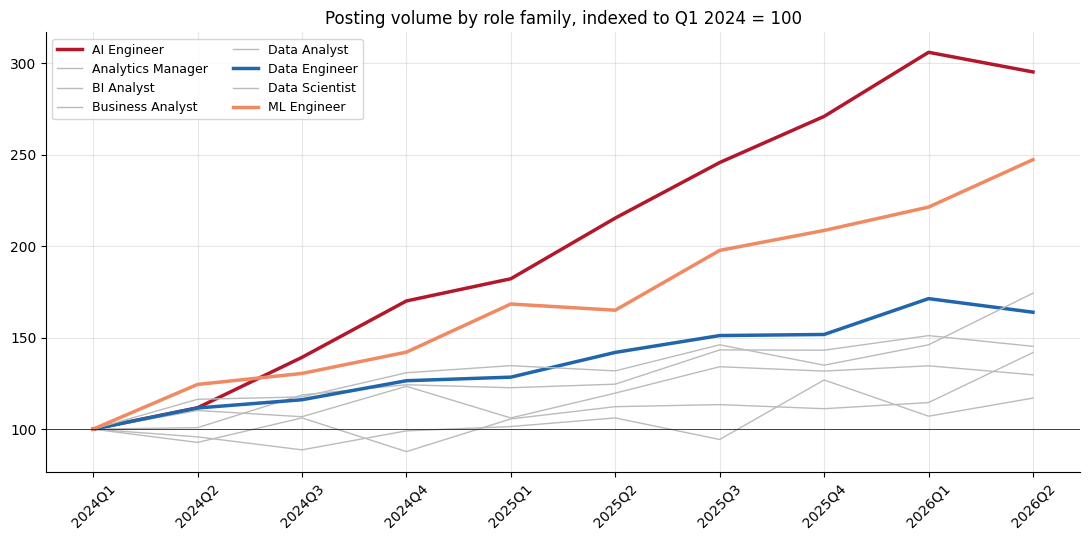

Growth Q1 2024 -> Q2 2026 (%):
role_family
AI Engineer          195.0
ML Engineer          147.0
Data Scientist        74.0
Data Engineer         64.0
Data Analyst          45.0
Analytics Manager     42.0
BI Analyst            30.0
Business Analyst      17.0


In [2]:
quarterly = (posts.groupby(["post_quarter", "role_family"]).size()
             .unstack(fill_value=0))
indexed = quarterly / quarterly.iloc[0] * 100

fig, ax = plt.subplots(figsize=(11, 5.5))
highlight = {"AI Engineer": "#b2182b", "ML Engineer": "#ef8a62", "Data Engineer": "#2166ac"}
for col in indexed.columns:
    color = highlight.get(col, "#bbbbbb")
    lw = 2.5 if col in highlight else 1
    ax.plot(indexed.index, indexed[col], label=col, color=color, lw=lw)
ax.axhline(100, color="black", lw=0.5)
ax.legend(ncol=2, fontsize=9)
ax.set_title("Posting volume by role family, indexed to Q1 2024 = 100")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../charts/01_role_growth.png", dpi=120)
plt.show()

growth = (quarterly.iloc[-1] / quarterly.iloc[0] - 1).sort_values(ascending=False) * 100
print("Growth Q1 2024 -> Q2 2026 (%):")
print(growth.round(0).to_string())

## 2. Skill demand: what's rising, what's fading

Share of postings mentioning each skill, first half of 2024 vs first half
of 2026.

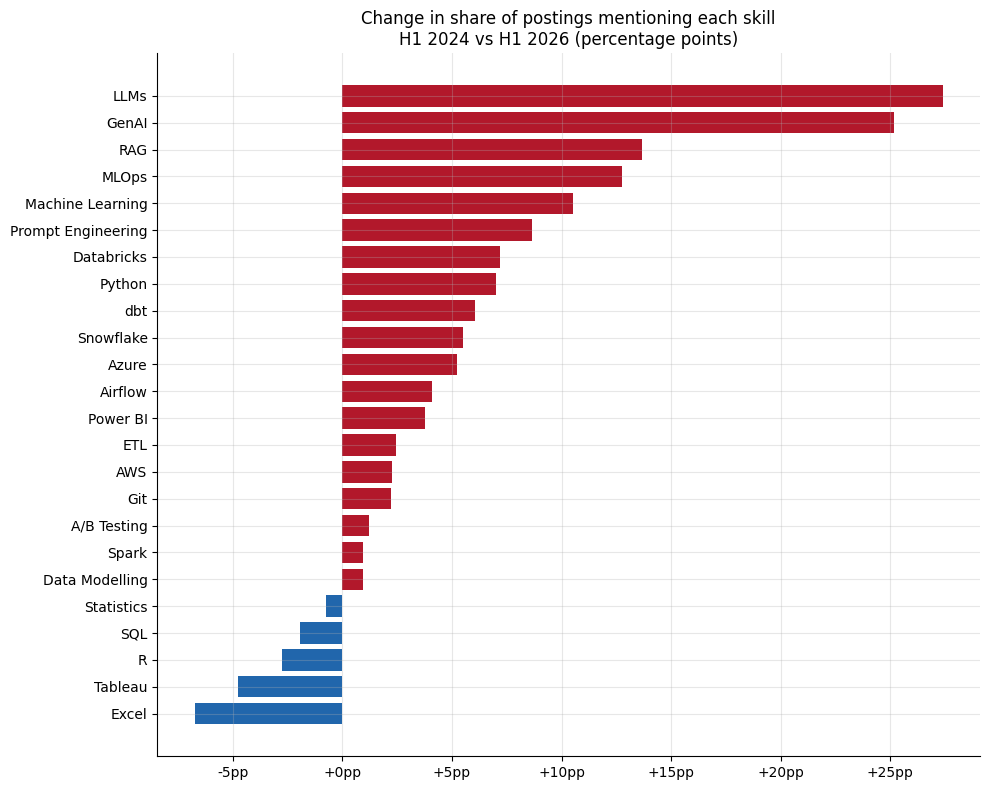

period              H1 2024  H1 2026  change
skill                                       
LLMs                    8.4     35.8    27.4
GenAI                   7.3     32.5    25.2
RAG                     3.4     17.0    13.7
MLOps                  12.0     24.8    12.8
Machine Learning       33.4     43.9    10.5
Prompt Engineering      3.0     11.6     8.7
Databricks             12.7     19.8     7.2
Python                 55.8     62.8     7.0


In [3]:
sk = skills.merge(posts[["posting_id", "post_month"]], on="posting_id")
sk["period"] = np.where(sk["post_month"] <= "2024-06", "H1 2024",
               np.where(sk["post_month"] >= "2026-01", "H1 2026", "mid"))

posts["period"] = np.where(posts["post_month"] <= "2024-06", "H1 2024",
                  np.where(posts["post_month"] >= "2026-01", "H1 2026", "mid"))
denom = posts[posts.period != "mid"].groupby("period").size()

share = (sk[sk.period != "mid"].groupby(["period", "skill"]).size()
         .unstack(level=0)
         .div(denom) * 100)
share["change"] = share["H1 2026"] - share["H1 2024"]
movers = share.sort_values("change")

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#b2182b" if v > 0 else "#2166ac" for v in movers["change"]]
ax.barh(movers.index, movers["change"], color=colors)
ax.set_title("Change in share of postings mentioning each skill\nH1 2024 vs H1 2026 (percentage points)")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:+.0f}pp"))
plt.tight_layout()
plt.savefig("../charts/02_skill_movers.png", dpi=120)
plt.show()

print(share.sort_values("change", ascending=False).round(1).head(8))

## 3. The GenAI skill explosion, month by month

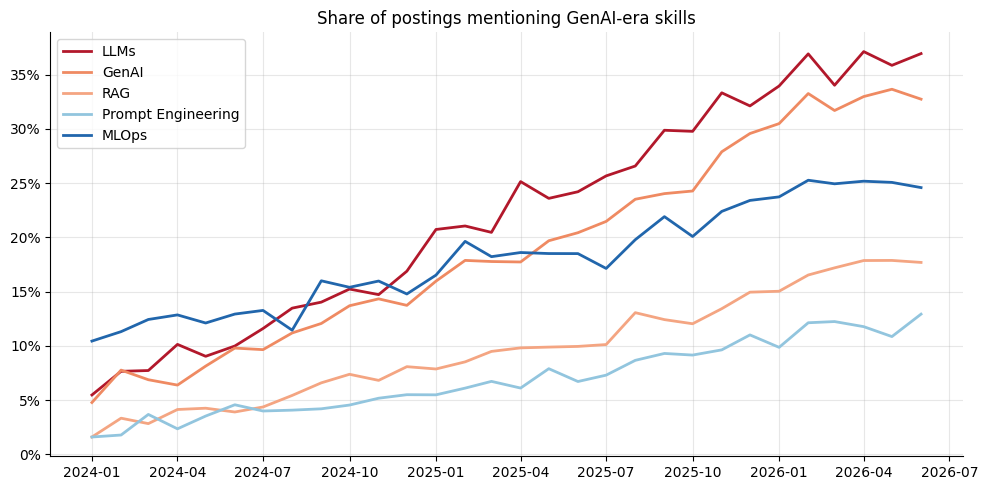

In [4]:
genai_skills = ["LLMs", "GenAI", "RAG", "Prompt Engineering", "MLOps"]
monthly_posts = posts.groupby("post_month").size()

fig, ax = plt.subplots()
for s, color in zip(genai_skills, ["#b2182b", "#ef8a62", "#f4a582", "#92c5de", "#2166ac"]):
    mentions = (sk[sk.skill == s].groupby("post_month").size()
                .reindex(monthly_posts.index, fill_value=0) / monthly_posts * 100)
    ax.plot(pd.to_datetime(mentions.index), mentions.values, label=s, color=color, lw=2)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.legend()
ax.set_title("Share of postings mentioning GenAI-era skills")
plt.tight_layout()
plt.savefig("../charts/03_genai_skills.png", dpi=120)
plt.show()

## 4. Salaries: role, city and the AI premium

Only the ~62% of postings that disclose a figure. Medians throughout.

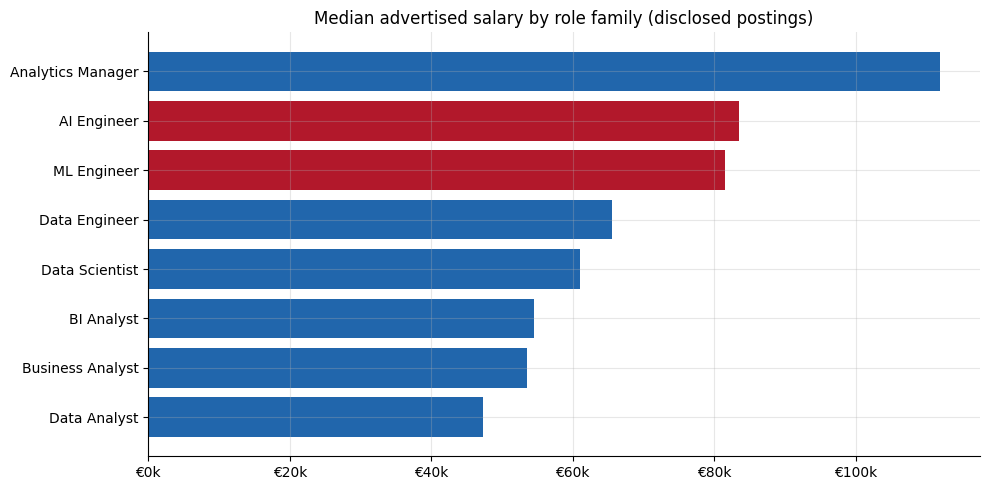

AI/ML median: €82,500  |  other data roles: €58,000  |  premium: 42%


In [5]:
sal = posts[posts.salary_disclosed == 1].copy()

by_role = (sal.groupby("role_family")["salary_mid_eur"].median()
           .sort_values())
fig, ax = plt.subplots()
colors = ["#b2182b" if r in ("AI Engineer", "ML Engineer") else "#2166ac"
          for r in by_role.index]
ax.barh(by_role.index, by_role.values, color=colors)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
ax.set_title("Median advertised salary by role family (disclosed postings)")
plt.tight_layout()
plt.savefig("../charts/04_salary_by_role.png", dpi=120)
plt.show()

ai_median = sal[sal.role_family.isin(["AI Engineer","ML Engineer"])]["salary_mid_eur"].median()
rest_median = sal[~sal.role_family.isin(["AI Engineer","ML Engineer"])]["salary_mid_eur"].median()
print(f"AI/ML median: €{ai_median:,.0f}  |  other data roles: €{rest_median:,.0f}"
      f"  |  premium: {(ai_median/rest_median-1)*100:.0f}%")

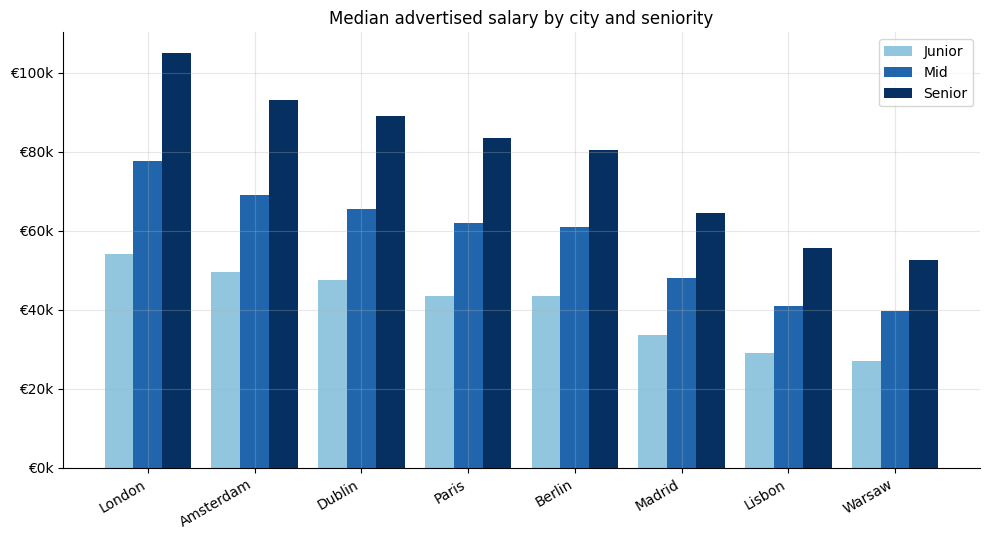

In [6]:
pivot = (sal.pivot_table(index="city", columns="seniority",
                         values="salary_mid_eur", aggfunc="median")
         [["Junior", "Mid", "Senior"]]
         .sort_values("Mid", ascending=False))

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(pivot))
w = 0.27
for i, (lvl, color) in enumerate(zip(["Junior","Mid","Senior"], ["#92c5de","#2166ac","#053061"])):
    ax.bar(x + (i-1)*w, pivot[lvl], w, label=lvl, color=color)
ax.set_xticks(x); ax.set_xticklabels(pivot.index, rotation=30, ha="right")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"€{y/1000:.0f}k"))
ax.legend()
ax.set_title("Median advertised salary by city and seniority")
plt.tight_layout()
plt.savefig("../charts/05_salary_by_city.png", dpi=120)
plt.show()

## 5. Remote work: quietly shrinking

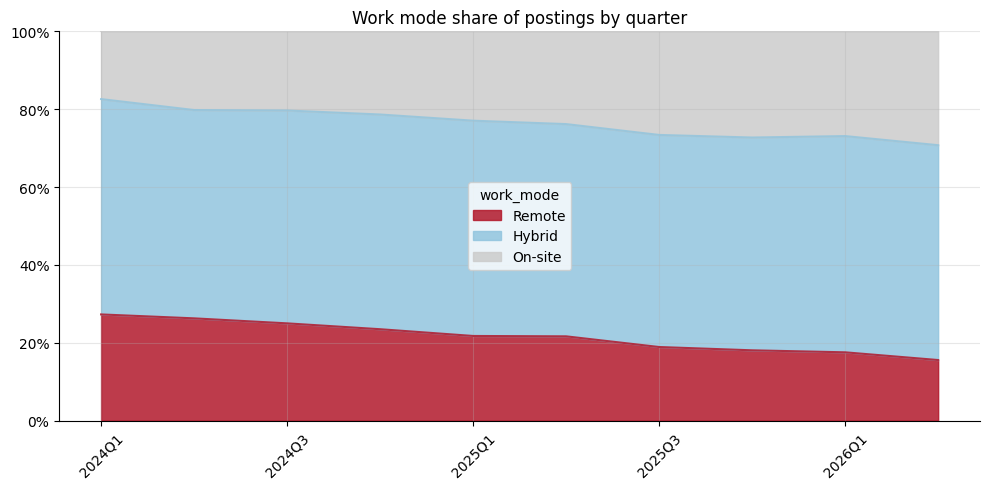

Remote share: 27% (Q1 2024) -> 16% (Q2 2026)


In [7]:
mode_share = (posts.groupby(["post_quarter", "work_mode"]).size()
              .unstack().apply(lambda r: r / r.sum(), axis=1) * 100)

ax = mode_share[["Remote", "Hybrid", "On-site"]].plot(
    kind="area", stacked=True, color=["#b2182b", "#92c5de", "#cccccc"], alpha=0.85)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.set_ylim(0, 100)
ax.set_title("Work mode share of postings by quarter")
ax.set_xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../charts/06_remote_share.png", dpi=120)
plt.show()

print(f"Remote share: {mode_share['Remote'].iloc[0]:.0f}% (Q1 2024) -> "
      f"{mode_share['Remote'].iloc[-1]:.0f}% (Q2 2026)")

## 6. Skill pairings: what to learn together

For the top skills, which other skill appears most often in the same
posting - a co-occurrence view of how employers bundle requirements.

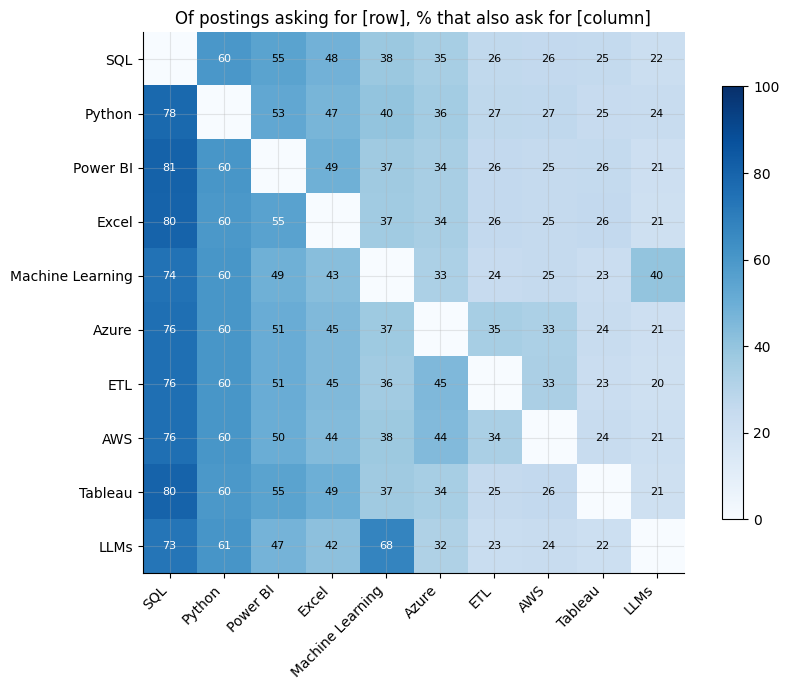

In [8]:
top_skills = skills["skill"].value_counts().head(10).index
merged = skills[skills.skill.isin(top_skills)]
pairs = merged.merge(merged, on="posting_id")
co = (pairs[pairs.skill_x != pairs.skill_y]
      .groupby(["skill_x", "skill_y"]).size().unstack(fill_value=0))
posting_counts = skills[skills.skill.isin(top_skills)]["skill"].value_counts()
co_pct = co.div(posting_counts, axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(co_pct.loc[top_skills, top_skills], cmap="Blues", vmin=0, vmax=100)
ax.set_xticks(range(len(top_skills))); ax.set_xticklabels(top_skills, rotation=45, ha="right")
ax.set_yticks(range(len(top_skills))); ax.set_yticklabels(top_skills)
for i in range(len(top_skills)):
    for j in range(len(top_skills)):
        if i != j:
            v = co_pct.loc[top_skills[i], top_skills[j]]
            ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                    color="white" if v > 55 else "black", fontsize=8)
ax.set_title("Of postings asking for [row], % that also ask for [column]")
plt.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.savefig("../charts/07_skill_cooccurrence.png", dpi=120)
plt.show()

## Findings

- AI Engineer postings roughly tripled over the period; ML Engineer nearly
  doubled. Business Analyst was the only family to shrink.
- The biggest skill gainers are GenAI-era: LLMs, GenAI, RAG and prompt
  engineering all went from near zero to a visible share of postings.
  Databricks and dbt grew strongly too. Excel, Tableau and R lost ground.
- SQL is still the single most requested skill. The boring answer to
  "what should I learn first" hasn't changed.
- AI/ML roles carry a clear salary premium over the rest of the market,
  and London pays the most at every seniority level in this dataset.
- Advertised remote share fell steadily; hybrid is the default.
- The co-occurrence matrix shows SQL+Python as the core pairing, with
  Power BI attaching to the analyst cluster and cloud/warehouse skills
  attaching to the engineering cluster.

**Caveats:** simulated data modelled on published market reports, so treat
the numbers as illustrative of the method rather than market truth. Only
62% of postings disclose salary, and disclosure itself may be biased
(companies paying above market are likelier to advertise it). Skill
extraction is keyword-based and will miss synonyms ("Pandas" doesn't count
as Python here).